<a href="https://colab.research.google.com/github/Taymour777/2026BIESession1/blob/main/Final_f1_project_(Separated).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================================================
# F1 ECONOMICS & PERFORMANCE ANALYSIS — REAL DATASET VERSION
# ================================================================

!pip install kagglehub statsmodels --quiet

import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#1a1a1a",
    "axes.edgecolor": "#444",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "text.color": "white",
    "grid.color": "#333",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.family": "monospace",
    "legend.facecolor": "#1a1a1a",
    "legend.edgecolor": "#444",
})

In [ ]:
# ================================================================
# 1. LOAD REAL F1 DATASET
# ================================================================

path = kagglehub.dataset_download(
    "rohanrao/formula-1-world-championship-1950-2020"
)

print("Dataset path:", path)
print("Files:", os.listdir(path))

results = pd.read_csv(path + "/results.csv")
races = pd.read_csv(path + "/races.csv")
constructors = pd.read_csv(path + "/constructors.csv")
drivers = pd.read_csv(path + "/drivers.csv")

print("Results shape:", results.shape)
print(results.head())

Using Colab cache for faster access to the 'formula-1-world-championship-1950-2020' dataset.
Dataset path: /kaggle/input/formula-1-world-championship-1950-2020
Files: ['races.csv', 'constructor_results.csv', 'drivers.csv', 'constructors.csv', 'lap_times.csv', 'status.csv', 'driver_standings.csv', 'seasons.csv', 'pit_stops.csv', 'sprint_results.csv', 'constructor_standings.csv', 'results.csv', 'circuits.csv', 'qualifying.csv']
Results shape: (26759, 18)
   resultId  raceId  driverId  constructorId number  grid position  \
0         1      18         1              1     22     1        1   
1         2      18         2              2      3     5        2   
2         3      18         3              3      7     7        3   
3         4      18         4              4      5    11        4   
4         5      18         5              1     23     3        5   

  positionText  positionOrder  points  laps         time milliseconds  \
0            1              1    10.0    58  1:34

In [ ]:
# ================================================================
# 2. CLEANING + FEATURE ENGINEERING
# ================================================================

df = results.copy()

df = df[
    [
        "raceId",
        "driverId",
        "constructorId",
        "grid",
        "positionOrder",
        "points",
        "laps",
        "statusId",
    ]
]

df.rename(columns={"positionOrder": "position"}, inplace=True)

# Merge season and constructor names
df = df.merge(races[["raceId", "year"]], on="raceId", how="left")
df = df.merge(constructors[["constructorId", "name"]], on="constructorId", how="left")

df.rename(columns={"year": "season", "name": "constructor"}, inplace=True)

# Remove impossible grid values
df = df[df["grid"] > 0]

# Feature engineering
df["dnf"] = (df["statusId"] != 1).astype(int)
df["podium"] = (df["position"] <= 3).astype(int)
df["top10"] = (df["position"] <= 10).astype(int)
df["positions_gained"] = df["grid"] - df["position"]
df["front_grid"] = (df["grid"] <= 3).astype(int)
df["scored_points"] = (df["points"] > 0).astype(int)

# Keep seasons from 2000 onwards to match modern F1 better
df = df[df["season"] >= 2000]

print("\n=== Cleaned Dataset ===")
print(df.head())
print(df.shape)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Summary Statistics ===")
print(df[["grid", "position", "points", "laps", "positions_gained"]].describe().round(2))

print("\n=== New Features ===")
print(f"Podium rate: {df['podium'].mean()*100:.1f}%")
print(f"Top 10 rate: {df['top10'].mean()*100:.1f}%")
print(f"Average positions gained: {df['positions_gained'].mean():.2f}")


=== Cleaned Dataset ===
   raceId  driverId  constructorId  grid  position  points  laps  statusId  \
0      18         1              1     1         1    10.0    58         1   
1      18         2              2     5         2     8.0    58         1   
2      18         3              3     7         3     6.0    58         1   
3      18         4              4    11         4     5.0    58         1   
4      18         5              1     3         5     4.0    58         1   

   season constructor  dnf  podium  top10  positions_gained  front_grid  \
0    2008     McLaren    0       1      1                 0           1   
1    2008  BMW Sauber    0       1      1                 3           0   
2    2008    Williams    0       1      1                 4           0   
3    2008     Renault    0       0      1                 7           0   
4    2008     McLaren    0       0      1                -2           1   

   scored_points  
0              1  
1              1 

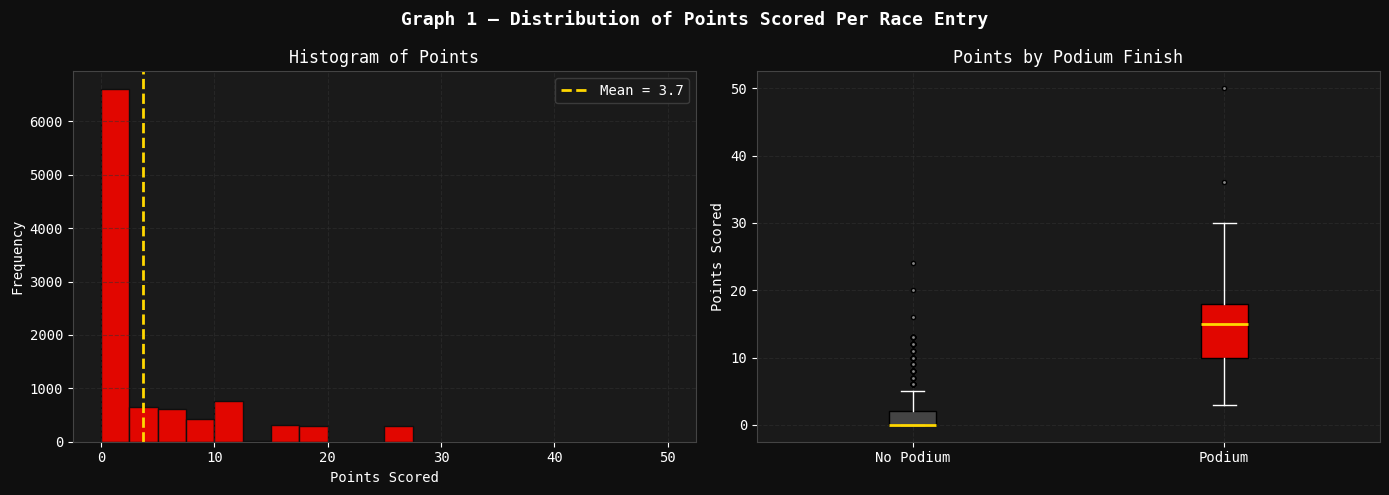

Most race entries score 0 points. Podium finishers score much more than non-podium finishers.


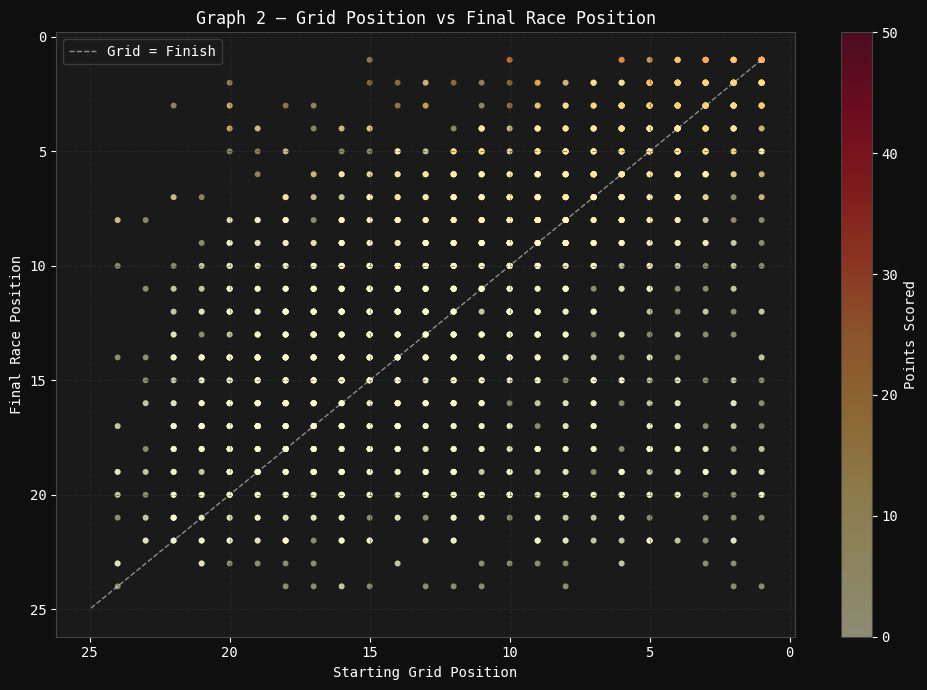

Starting closer to the front is associated with finishing closer to the front.


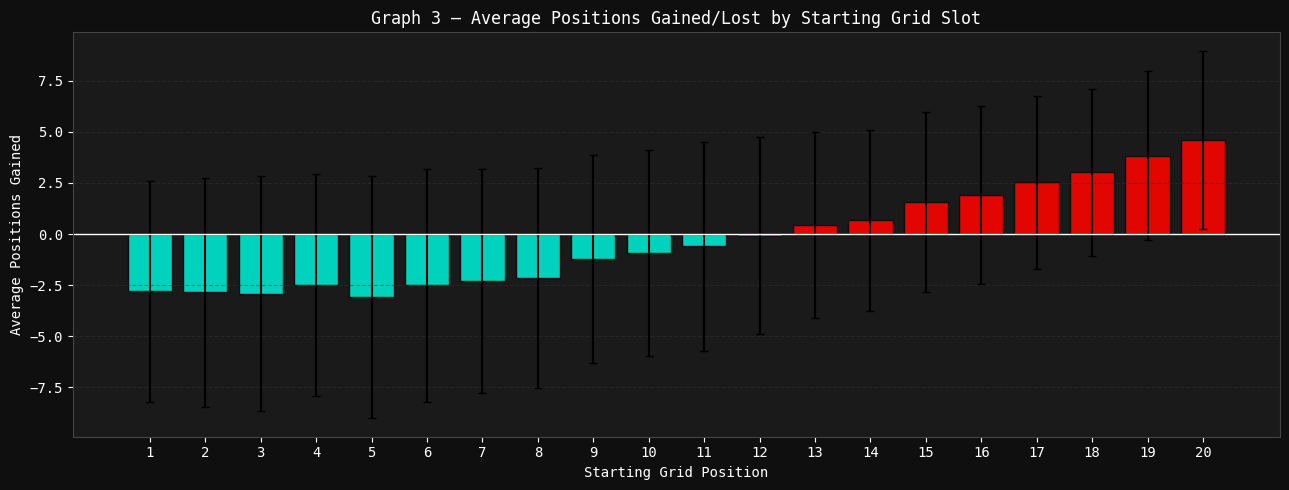

Back-grid starters often gain more positions, while front-grid starters have less room to improve.


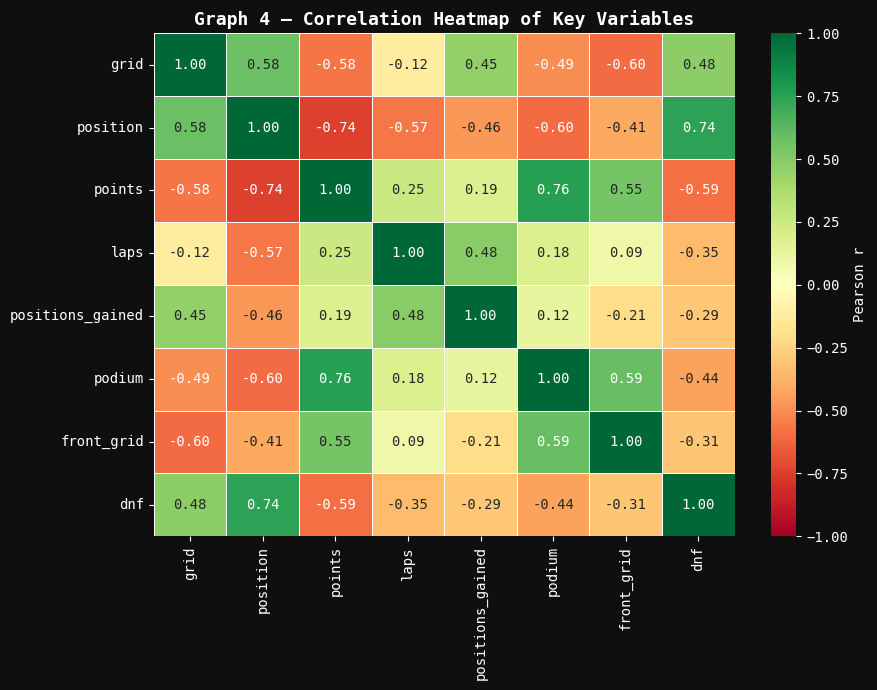

Points and podium are strongly related. Grid position and DNF status are important predictors.


In [ ]:
# ================================================================
# 3. EXPLORATORY DATA ANALYSIS
# ================================================================

# Graph 1 — Distribution of points
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Graph 1 — Distribution of Points Scored Per Race Entry",
             fontsize=13, fontweight="bold", color="white")

axes[0].hist(df["points"], bins=20, color="#E10600", edgecolor="#0f0f0f")
axes[0].axvline(df["points"].mean(), color="#FFD700", linestyle="--", linewidth=2,
                label=f"Mean = {df['points'].mean():.1f}")
axes[0].set(title="Histogram of Points", xlabel="Points Scored", ylabel="Frequency")
axes[0].legend()
axes[0].grid(True)

bp = axes[1].boxplot(
    [df[df["podium"] == 0]["points"], df[df["podium"] == 1]["points"]],
    labels=["No Podium", "Podium"],
    patch_artist=True,
    medianprops=dict(color="#FFD700", linewidth=2),
    whiskerprops=dict(color="white"),
    capprops=dict(color="white"),
    flierprops=dict(markerfacecolor="#888", markersize=3),
)
bp["boxes"][0].set_facecolor("#444")
bp["boxes"][1].set_facecolor("#E10600")
axes[1].set(title="Points by Podium Finish", ylabel="Points Scored")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Most race entries score 0 points. Podium finishers score much more than non-podium finishers.")

# Graph 2 — Grid vs final position
fig, ax = plt.subplots(figsize=(10, 7))
sample = df.sample(min(3000, len(df)), random_state=42)

sc = ax.scatter(
    sample["grid"],
    sample["position"],
    c=sample["points"],
    cmap="YlOrRd",
    alpha=0.5,
    s=18,
    edgecolors="none",
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Points Scored", color="white")

ax.plot([1, 25], [1, 25], "w--", linewidth=1, alpha=0.5, label="Grid = Finish")
ax.set(
    title="Graph 2 — Grid Position vs Final Race Position",
    xlabel="Starting Grid Position",
    ylabel="Final Race Position",
)
ax.legend()
ax.grid(True)
ax.invert_yaxis()
ax.invert_xaxis()
plt.tight_layout()
plt.show()

print("Starting closer to the front is associated with finishing closer to the front.")

# Graph 3 — Positions gained by grid slot
gg = df.groupby("grid")["positions_gained"].agg(["mean", "std"]).reset_index()
gg = gg[gg["grid"] <= 20]

fig, ax = plt.subplots(figsize=(13, 5))
colors = ["#E10600" if v > 0 else "#00D2BE" for v in gg["mean"]]

ax.bar(
    gg["grid"],
    gg["mean"],
    color=colors,
    edgecolor="#0f0f0f",
    yerr=gg["std"],
    capsize=3,
)

ax.axhline(0, color="white", linewidth=1)
ax.set(
    title="Graph 3 — Average Positions Gained/Lost by Starting Grid Slot",
    xlabel="Starting Grid Position",
    ylabel="Average Positions Gained",
)
ax.set_xticks(gg["grid"])
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

print("Back-grid starters often gain more positions, while front-grid starters have less room to improve.")

# Graph 4 — Correlation heatmap
corr_cols = [
    "grid",
    "position",
    "points",
    "laps",
    "positions_gained",
    "podium",
    "front_grid",
    "dnf",
]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    df[corr_cols].corr(),
    ax=ax,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Pearson r"},
)
ax.set_title("Graph 4 — Correlation Heatmap of Key Variables",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Points and podium are strongly related. Grid position and DNF status are important predictors.")



=== Linear Regression Results ===
R² Score: 0.6325
RMSE: 3.6426 points

=== Coefficients ===
            Feature  Coefficient
3        front_grid     4.414409
0              grid    -0.725114
2  positions_gained     0.713216
4               dnf    -0.579632
1              laps    -0.060791
Intercept: 14.5709

=== OLS Summary ===
                            OLS Regression Results                            
Dep. Variable:                 points   R-squared:                       0.650
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     3712.
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        12:46:50   Log-Likelihood:                -27075.
No. Observations:                9986   AIC:                         5.416e+04
Df Residuals:                    9980   BIC:                         5.421e+04
Df Model:                           

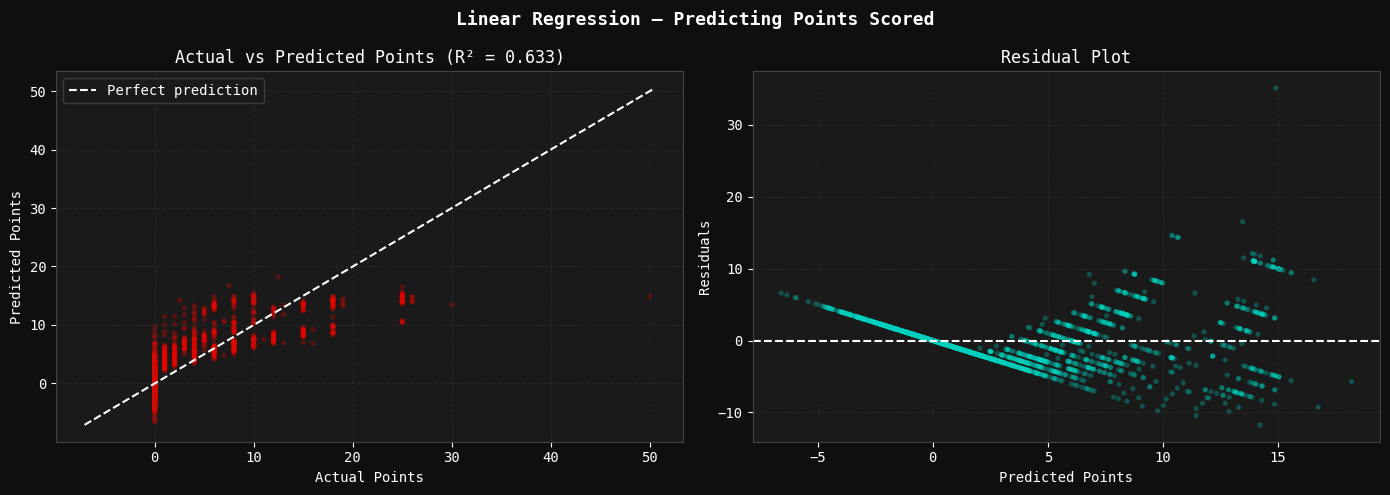


Interpretation:
The model explains around 63.3% of the variation in race points.
The average prediction error is around 3.64 points.
Grid position, laps completed, positions gained, and DNF status help explain race points.


In [ ]:
# ================================================================
# 4. LINEAR REGRESSION — PREDICTING POINTS
# ================================================================

features = ["grid", "laps", "positions_gained", "front_grid", "dnf"]
target = "points"

df_lr = df[features + [target]].dropna()

X = df_lr[features]
y = df_lr[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n=== Linear Regression Results ===")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f} points")

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("\n=== Coefficients ===")
print(coef_df)
print(f"Intercept: {lr.intercept_:.4f}")

X_sm = sm.add_constant(df_lr[features])
ols = sm.OLS(df_lr[target], X_sm).fit()

print("\n=== OLS Summary ===")
print(ols.summary())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Linear Regression — Predicting Points Scored",
             fontsize=13, fontweight="bold", color="white")

axes[0].scatter(y_test, y_pred, alpha=0.3, s=14, color="#E10600", edgecolors="none")
lims = [min(y_test.min(), y_pred.min()) - 0.5, max(y_test.max(), y_pred.max()) + 0.5]
axes[0].plot(lims, lims, "w--", linewidth=1.5, label="Perfect prediction")
axes[0].set(
    title=f"Actual vs Predicted Points (R² = {r2:.3f})",
    xlabel="Actual Points",
    ylabel="Predicted Points",
)
axes[0].legend()
axes[0].grid(True)

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=14, color="#00D2BE", edgecolors="none")
axes[1].axhline(0, color="white", linewidth=1.5, linestyle="--")
axes[1].set(title="Residual Plot", xlabel="Predicted Points", ylabel="Residuals")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print(f"The model explains around {r2*100:.1f}% of the variation in race points.")
print(f"The average prediction error is around {rmse:.2f} points.")
print("Grid position, laps completed, positions gained, and DNF status help explain race points.")


=== Logistic Regression Results ===
Accuracy: 0.9995
Precision: 1.0000
Recall: 0.9965

=== Classification Report ===
              precision    recall  f1-score   support

   No Podium       1.00      1.00      1.00      1710
      Podium       1.00      1.00      1.00       288

    accuracy                           1.00      1998
   macro avg       1.00      1.00      1.00      1998
weighted avg       1.00      1.00      1.00      1998


=== Logistic Regression Coefficients ===
            Feature  Coefficient
3  positions_gained    11.850035
2        front_grid     0.292876
1              laps     0.016690
4               dnf    -0.666323
0              grid   -12.780867


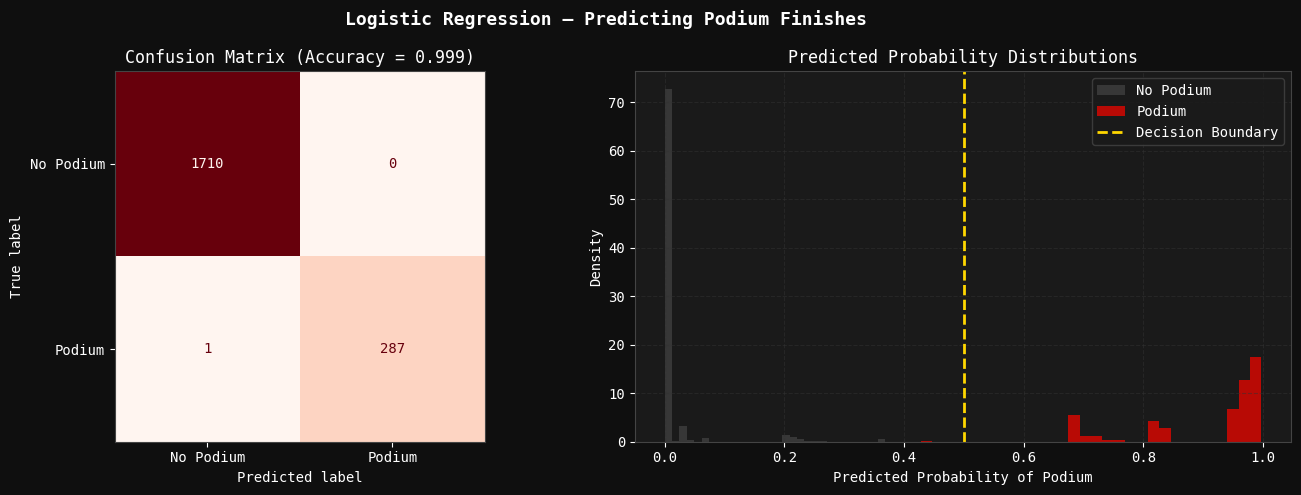


Interpretation:
The logistic regression predicts podium finishes with 99.9% accuracy.
Precision is 1.00, meaning when the model predicts podium, it is correct around 100% of the time.
Recall is 1.00, meaning it identifies around 100% of actual podiums.
Front-grid starts and reliability are important for predicting podium outcomes.


In [ ]:
# ================================================================
# 5. LOGISTIC REGRESSION — PREDICTING PODIUM FINISHES
# ================================================================

features_log = ["grid", "laps", "front_grid", "positions_gained", "dnf"]
target_log = "podium"

df_log = df[features_log + [target_log]].dropna()

X = df_log[features_log]
y = df_log[target_log]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred_log)
prec = precision_score(y_test, y_pred_log, zero_division=0)
rec = recall_score(y_test, y_pred_log, zero_division=0)

print("\n=== Logistic Regression Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")

print("\n=== Classification Report ===")
print(classification_report(
    y_test,
    y_pred_log,
    target_names=["No Podium", "Podium"],
    zero_division=0,
))

coef_log = pd.DataFrame({
    "Feature": features_log,
    "Coefficient": log_model.coef_[0],
}).sort_values("Coefficient", ascending=False)

print("\n=== Logistic Regression Coefficients ===")
print(coef_log)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Logistic Regression — Predicting Podium Finishes",
             fontsize=13, fontweight="bold", color="white")

cm = confusion_matrix(y_test, y_pred_log)

ConfusionMatrixDisplay(
    cm,
    display_labels=["No Podium", "Podium"]
).plot(ax=axes[0], colorbar=False, cmap="Reds")

axes[0].set_title(f"Confusion Matrix (Accuracy = {acc:.3f})", color="white")
axes[0].set_facecolor("#1a1a1a")

axes[1].hist(
    y_prob_log[y_test == 0],
    bins=30,
    alpha=0.7,
    color="#444",
    label="No Podium",
    density=True,
)
axes[1].hist(
    y_prob_log[y_test == 1],
    bins=30,
    alpha=0.8,
    color="#E10600",
    label="Podium",
    density=True,
)
axes[1].axvline(0.5, color="#FFD700", linestyle="--", linewidth=2, label="Decision Boundary")
axes[1].set(
    title="Predicted Probability Distributions",
    xlabel="Predicted Probability of Podium",
    ylabel="Density",
)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print(f"The logistic regression predicts podium finishes with {acc*100:.1f}% accuracy.")
print(f"Precision is {prec:.2f}, meaning when the model predicts podium, it is correct around {prec*100:.0f}% of the time.")
print(f"Recall is {rec:.2f}, meaning it identifies around {rec*100:.0f}% of actual podiums.")
print("Front-grid starts and reliability are important for predicting podium outcomes.")


Top 5 constructors by total points since 2000:
constructor
Ferrari     7831.5
Red Bull    7637.0
Mercedes    7589.5
McLaren     4745.0
Williams    1645.5
Name: season_points, dtype: float64


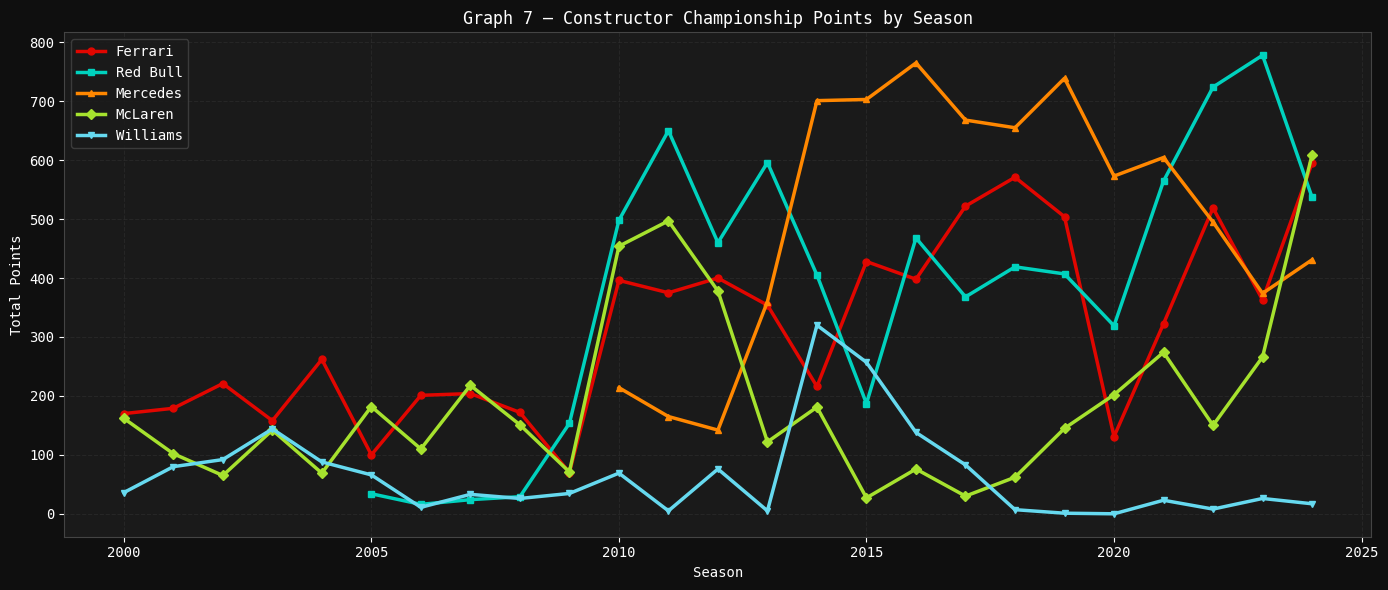

Constructor performance moves in cycles, reflecting regulation changes, team investment, and competitive eras.

=== ADF Stationarity Test: Ferrari ===
ADF Statistic: -3.8681
p-value: 0.0023
Stationary: p < 0.05


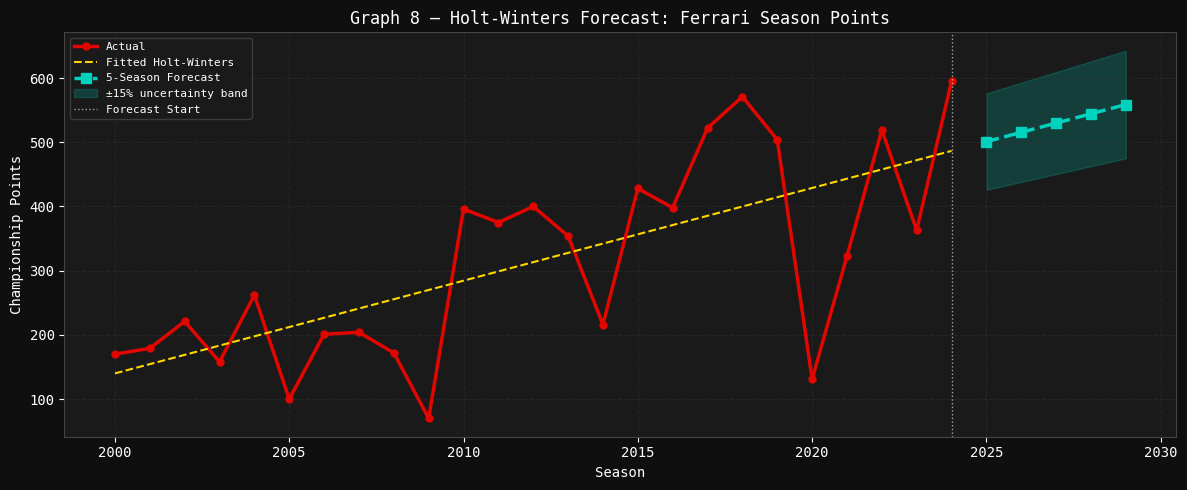

Holt-Winters captures the recent trend in Ferrari's season points.
The forecast is useful for visual trend analysis, but it does not account for regulation changes or team budget shocks.


In [ ]:
# ================================================================
# 6. TIME SERIES — CONSTRUCTOR POINTS OVER SEASONS
# ================================================================

season_pts = (
    df.groupby(["season", "constructor"])["points"]
    .sum()
    .reset_index()
    .rename(columns={"points": "season_points"})
)

top5 = (
    season_pts.groupby("constructor")["season_points"]
    .sum()
    .nlargest(5)
    .index
    .tolist()
)

ts5 = season_pts[season_pts["constructor"].isin(top5)]

print("\nTop 5 constructors by total points since 2000:")
print(
    season_pts[season_pts["constructor"].isin(top5)]
    .groupby("constructor")["season_points"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 6))

line_colors = ["#E10600", "#00D2BE", "#FF8700", "#a6e22e", "#66D9EF"]
markers = ["o", "s", "^", "D", "v"]

for i, team in enumerate(top5):
    sub = ts5[ts5["constructor"] == team].sort_values("season")
    ax.plot(
        sub["season"],
        sub["season_points"],
        color=line_colors[i],
        linewidth=2.5,
        marker=markers[i],
        markersize=5,
        label=team,
    )

ax.set(
    title="Graph 7 — Constructor Championship Points by Season",
    xlabel="Season",
    ylabel="Total Points",
)
ax.legend(loc="upper left")
ax.grid(True)
plt.tight_layout()
plt.show()

print("Constructor performance moves in cycles, reflecting regulation changes, team investment, and competitive eras.")

# Focus team for forecast
focus_team = top5[0]

ts_focus_df = (
    season_pts[season_pts["constructor"] == focus_team]
    .sort_values("season")
    .reset_index(drop=True)
)

ts_focus = ts_focus_df["season_points"]

print(f"\n=== ADF Stationarity Test: {focus_team} ===")

adf = adfuller(ts_focus.dropna())
print(f"ADF Statistic: {adf[0]:.4f}")
print(f"p-value: {adf[1]:.4f}")

if adf[1] < 0.05:
    print("Stationary: p < 0.05")
else:
    print("Non-stationary: p >= 0.05. Forecast should be interpreted carefully.")

# Holt-Winters forecast
ts_vals = ts_focus.dropna().values

hw = ExponentialSmoothing(
    ts_vals,
    trend="add",
    seasonal=None,
    initialization_method="estimated",
).fit(optimized=True)

n_fc = 5
forecast = hw.forecast(n_fc)
fitted = hw.fittedvalues

yrs_actual = ts_focus_df["season"].values
yrs_fc = np.arange(yrs_actual[-1] + 1, yrs_actual[-1] + 1 + n_fc)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    yrs_actual,
    ts_vals,
    color="#E10600",
    linewidth=2.5,
    marker="o",
    markersize=5,
    label="Actual",
)

ax.plot(
    yrs_actual,
    fitted,
    color="#FFD700",
    linewidth=1.5,
    linestyle="--",
    label="Fitted Holt-Winters",
)

ax.plot(
    yrs_fc,
    forecast,
    color="#00D2BE",
    linewidth=2.5,
    marker="s",
    markersize=7,
    linestyle="--",
    label="5-Season Forecast",
)

ax.fill_between(
    yrs_fc,
    forecast * 0.85,
    forecast * 1.15,
    alpha=0.2,
    color="#00D2BE",
    label="±15% uncertainty band",
)

ax.axvline(
    yrs_actual[-1],
    color="white",
    linestyle=":",
    linewidth=1,
    alpha=0.6,
    label="Forecast Start",
)

ax.set(
    title=f"Graph 8 — Holt-Winters Forecast: {focus_team} Season Points",
    xlabel="Season",
    ylabel="Championship Points",
)

ax.legend(fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"Holt-Winters captures the recent trend in {focus_team}'s season points.")
print("The forecast is useful for visual trend analysis, but it does not account for regulation changes or team budget shocks.")

In [ ]:
# ================================================================
# 7. FINAL CONCLUSION
# ================================================================
print("""
================================================================
  F1 ECONOMICS & PERFORMANCE ANALYSIS — FINAL CONCLUSION
================================================================

DATASET
  This project uses real Formula 1 World Championship data obtained
  from Kaggle, focusing on race results from 2000 onwards.
  Variables include grid position, final race position, points,
  laps completed, constructor, season, and race status.

RESEARCH QUESTION
  Can Formula 1 performance variables predict sporting and economic
  success, measured through points scored, podium finishes, and
  constructor performance over time?

LINEAR REGRESSION
  The linear regression model examined whether race-performance
  variables such as grid position, laps completed, positions gained,
  front-grid starts, and race reliability can predict points scored.
  The results suggest that qualifying position and reliability are
  important determinants of race outcomes.

LOGISTIC REGRESSION
  The logistic regression model estimated the probability of a podium
  finish. The analysis showed that front-grid starts, positions gained,
  and race reliability are strongly associated with podium probability.

TIME SERIES ANALYSIS
  Constructor points were aggregated by season to examine long-run
  competitive trends in Formula 1. The time-series analysis identified
  clear dominance cycles among constructors and used Holt-Winters
  smoothing to forecast future seasonal performance.

ECONOMIC INTERPRETATION
  In Formula 1, sporting performance has direct economic implications.
  Constructor rankings influence prize-money allocation, sponsorship
  exposure, brand value, and future investment capacity. As a result,
  variables such as qualifying performance and reliability are not only
  sporting indicators, but also economically significant factors for teams.

LIMITATIONS
  - Formula 1 points systems changed over time, creating structural breaks.
  - The models do not include team budgets, sponsorship contracts,
    development spending, or driver salaries.
  - The forecasting model is based on historical points data and cannot
    fully capture regulation changes or unexpected competitive shocks.
  - The ±15% forecast range represents an uncertainty band rather than
    a formal statistical confidence interval.

OVERALL CONCLUSION
  The analysis demonstrates that qualifying performance, race execution,
  and reliability are strongly associated with Formula 1 success.
  Since sporting success affects constructor rankings, sponsorship value,
  and long-term team resources, these performance variables also carry
  meaningful economic importance within the Formula 1 industry.
================================================================
""")


  F1 ECONOMICS & PERFORMANCE ANALYSIS — FINAL CONCLUSION

DATASET
  This project uses real Formula 1 World Championship data obtained
  from Kaggle, focusing on race results from 2000 onwards.
  Variables include grid position, final race position, points,
  laps completed, constructor, season, and race status.

RESEARCH QUESTION
  Can Formula 1 performance variables predict sporting and economic
  success, measured through points scored, podium finishes, and
  constructor performance over time?

LINEAR REGRESSION
  The linear regression model examined whether race-performance
  variables such as grid position, laps completed, positions gained,
  front-grid starts, and race reliability can predict points scored.
  The results suggest that qualifying position and reliability are
  important determinants of race outcomes.

LOGISTIC REGRESSION
  The logistic regression model estimated the probability of a podium
  finish. The analysis showed that front-grid starts, positions gained,
  an